In [ ]:
from tqdm import tqdm
import matplotlib.pyplot as plt
from utils.preprocesamiento import read_reviews
from fastopic import FASTopic
from topmost import Preprocess
import spacy
import re
from sklearn.model_selection import train_test_split
import nltk
import numpy as np
import torch
from src.utils.config import reviews_fastopic_file

nltk.download('punkt_tab')      
nltk.download('wordnet')    
nltk.download('omw-1.4') 
nltk.download('averaged_perceptron_tagger_eng') 

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\imzli\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\imzli\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\imzli\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\imzli\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

**NOTA:** Este modelo no es 100% reproducible, ni estableciendo semillas, se deja este notebook con el entrenamiento y evaluación del modelo

In [41]:
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
tqdm.pandas(desc="Limpiando texto")

In [42]:
df = read_reviews()

In [43]:
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner", "textcat"])
def spacy_tokenizer(text):
    doc = nlp(text)
    return [
        token.lemma_.lower()
        for token in doc
        if not token.is_stop
        and not token.is_punct
        and not token.is_space
        and token.is_alpha
        and len(token.text) > 2
    ]

In [44]:
preprocess = Preprocess(vocab_size=2000, min_doc_count=100, max_doc_freq=0.5, tokenizer=spacy_tokenizer, seed=seed, verbose=True)
model = FASTopic(num_topics = 6, verbose= True, preprocess=preprocess,device="cuda", low_memory=True, low_memory_batch_size=50000,DT_alpha = 4,TW_alpha = 4)

2026-04-29 19:51:10,172 - FASTopic - use device: cuda


In [45]:
def remove_hearts(text):
    text = re.sub(r'(hearts){2,}', '', text)
    text = re.sub('heartsheart', '', text)
    text = re.sub('heart', '', text)
    return text
df["text_clean"] = df["text"].progress_apply(remove_hearts)

Limpiando texto: 100%|██████████| 205883/205883 [00:02<00:00, 92466.10it/s] 


In [ ]:
texts = df["text_clean"].astype(str).tolist()
# No es necesario estratificar, no es un problema de clasificación, pero se fija la semilla para reproducibilidad
texts_train, texts_test = train_test_split(texts, test_size=10, random_state=seed)

In [47]:
topic_top_words, doc_topic_dist = model.fit_transform(texts)

2026-04-29 19:51:18,002 - FASTopic - Using low memory mode.
2026-04-29 19:51:18,003 - FASTopic - First fit the model.
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 758.13it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
parsing texts: 100%|██████████| 205883/205883 [12:43<00:00, 269.63it/s]
c:\Users\imzli\Documents\Proyecto de Datos\c2526-R4\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
2026-04-29 20:29:15,577 - TopMost - Real vocab size: 2000
2026-04-29 20:29:15,583 - TopMost - Real training size: 205883 	 avg leng

Topic 0: steam free developer money update buy fix bug year devs pay release review crash gamer
Topic 1: war car shooter fire match strategy race win unit shoot defense physics tower arcade ball
Topic 2: amazing beautiful music horror highly cool original awesome perfect favorite soul series super fantastic soundtrack
Topic 3: player experience visual design character world narrative system feel offer mechanic focus sense choice puzzle
Topic 4: girl cute english room cat translation funny man crazy friend chinese word hate click fish
Topic 5: play like good time fun feel story great way lot thing love think want look


In [ ]:
path = reviews_fastopic_file
model.save(path)

In [76]:
topic_tags = {
    0: "Updates & Bugs",
    1: "Action & Combat",
    2: "Music & Atmosphere",
    3: "Story & Design",
    4: "Casual & Humor",
    5: "General Opinion",
}

In [ ]:
def load_model(path):
    loaded_model = FASTopic.from_pretrained(path)
    # daba errores de tensores en distintos dispositivos (cuda, cpu), así que se asegura que todo esté en CPU para evitar esos problemas
    loaded_model.model.to("cpu")
    loaded_model.train_doc_embeddings = loaded_model.train_doc_embeddings.to("cpu")
    if hasattr(loaded_model.model, 'topic_embeddings'):
        loaded_model.model.topic_embeddings = loaded_model.model.topic_embeddings.to("cpu")
    return loaded_model
loaded_model = load_model(reviews_fastopic_file)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1267.91it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [78]:
topic_dists = loaded_model.transform(texts_test)
for r, dist in zip(texts_test, topic_dists):
    topic_id = np.argmax(dist)
    print(f"Review: {r}... | Topic: {topic_tags[topic_id]}")

Review: chips chips chip! 5 stars!... | Topic: Casual & Humor
Review: highly recommend if you ever liked megaman battle network, you fully understand what this is going for. ive been playing this while playing fallout 3 and oblivion and ive been loving the heck outta it. it actually reminds me to save more often lol... | Topic: General Opinion
Review: its a small game but its really good. i hope the devs will make a complete version of the game... | Topic: Updates & Bugs
Review: pretty fun mechanics and enemies to deal with, but i got lost several playthroughs and couldnt figure out where to go from there. unfortunate, since i wanted to enjoy the game, but with its challenging nature and finding it impossible where it go, i just couldnt enjoy it.... | Topic: General Opinion
Review: i hope the devs  die and has a painful castration and get their  removed burn the devs burn the devs burn the devs burn the devs burn the devs burn the devs burn the devs burn the devs burn the devs burn the

In [86]:
topic_distribution = loaded_model.transform(["The game has amazing music and a captivating story"])
topic_id = np.argmax(topic_distribution)
topic_tags.get(topic_id)

'Music & Atmosphere'

In [87]:
topic_distribution = loaded_model.transform(["The game is full of bugs and crashes often"])
topic_id = np.argmax(topic_distribution)
topic_tags.get(topic_id)

'Updates & Bugs'

In [89]:
topic_distribution = loaded_model.transform(["The story is weak but the combat is fun and strategic"])
topic_id = np.argmax(topic_distribution)
topic_tags.get(topic_id)

'Story & Design'

In [90]:
def predict_topics(text, model, topic_tags):
    distribution = model.transform([text])
    topic_id = np.argmax(distribution)
    return topic_tags.get(topic_id)

In [91]:
topic_dists = loaded_model.transform(df["text_clean"].tolist())

In [93]:
df["predicted_topic"] = topic_dists.argmax(axis=1)
df["predicted_topic_label"] = df["predicted_topic"].map(topic_tags)
df

,appid,is_positive,weight,text,language,text_clean,predicted_topic,predicted_topic_label
1,747660,True,0.5,nothing,en,nothing,1,Action & Combat
3,747660,True,0.5,"so, i completed the game and got all the achie...",en,"so, i completed the game and got all the achie...",4,Casual & Humor
4,747660,True,0.5,its very good and worth the 40 bucks in my opi...,en,its very good and worth the 40 bucks in my opi...,2,Music & Atmosphere
8,747660,True,0.5,i like that its fun and has a lot of gameplay ...,en,i like that its fun and has a lot of gameplay ...,0,Updates & Bugs
10,747660,True,0.5,holds a special place in my heart,en,holds a special place in my,4,Casual & Humor
...,...,...,...,...,...,...,...,...
261267,3300800,True,0.5,insanely clever puzzles. relaxing music and vi...,en,insanely clever puzzles. relaxing music and vi...,3,Story & Design
261268,3300800,True,0.5,good puzzle game with mastercraft design,en,good puzzle game with mastercraft design,3,Story & Design
261269,3300800,True,0.5,"great game, small developer, cheap game, but r...",en,"great game, small developer, cheap game, but r...",2,Music & Atmosphere
261270,3300800,True,0.5,"love this game! 10/10, great puzzles and overa...",en,"love this game! 10/10, great puzzles and overa...",2,Music & Atmosphere


In [94]:
doc_topic_dist

array([[0.16675372, 0.20623757, 0.1203726 , 0.16813505, 0.20270735,
        0.13579367],
       [0.18712993, 0.16280168, 0.13938694, 0.12045824, 0.20304236,
        0.18718085],
       [0.1579038 , 0.1574856 , 0.20324366, 0.15165961, 0.14368013,
        0.18602721],
       ...,
       [0.1391058 , 0.13846517, 0.22801194, 0.17960466, 0.14013644,
        0.17467597],
       [0.12639903, 0.1217811 , 0.24300623, 0.16065532, 0.1701555 ,
        0.17800276],
       [0.12336261, 0.12119891, 0.22998954, 0.19977851, 0.15368316,
        0.17198727]], shape=(205883, 6), dtype=float32)

In [ ]:
fig = model.visualize_topic(top_n=10)
fig.for_each_annotation(lambda a: a.update(text=next((topic_tags[k] for k in topic_tags if f"Topic {k}" == a.text), a.text)))
fig.show()

"""TOPICS
- 0: "Updates & Bugs"
- 1: "Action & Combat"
- 2: "Music & Atmosphere"
- 3: "Story & Design"
- 4: "Casual & Humor"
- 5: "General Opinion"
"""

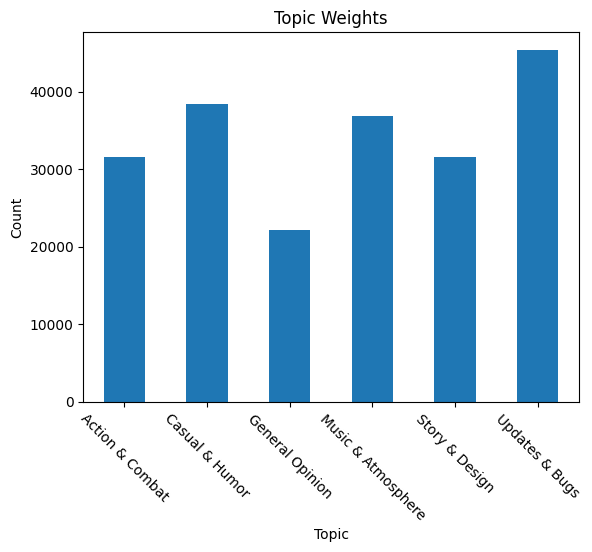

<Figure size 640x480 with 0 Axes>

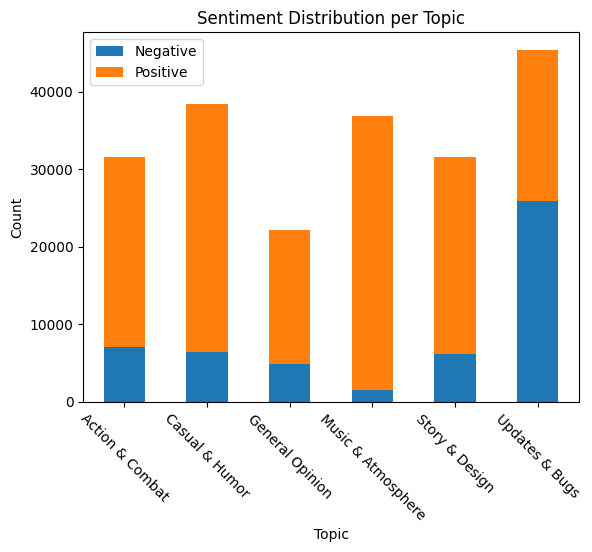

In [ ]:
topic_counts = df['predicted_topic_label'].value_counts().sort_index()

plt.figure()
topic_counts.plot(kind='bar')
plt.title("Topic Weights")
plt.xlabel("Topic")
plt.ylabel("Count")
plt.xticks(rotation=-45)
plt.show()


sentiment_counts = (
    df.groupby(['predicted_topic_label', 'is_positive'])
      .size()
      .unstack(fill_value=0)
      .sort_index()
)

plt.figure()
sentiment_counts.plot(kind='bar', stacked=True)
plt.title("Sentiment Distribution per Topic")
plt.xlabel("Topic")
plt.ylabel("Count")
plt.xticks(rotation=-45)
plt.legend(["Negative", "Positive"])
plt.show()